<a href="https://colab.research.google.com/github/Jonchyk/Datamgmt/blob/main/Capstone_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set Up

In [255]:
#---------------------------SETUP----------------------------------
#get useful libraries
import time, os, sys, re #basics
import zipfile, json, datetime, string   #string for annotating points in scatter
import numpy as np #basic math
# Install tabula-py using pip
!pip install tabula-py
# Import the correct module
from tabula import read_pdf
import statsmodels.api as sm
from statsmodels.formula.api import ols

!pip install pyreadstat


import matplotlib.pyplot as plt #import pylab as plt #apparently discouraged now:
 #https://stackoverflow.com/questions/11469336/what-is-the-difference-between-pylab-and-pyplot
 #https://www.tutorialspoint.com/matplotlib/matplotlib_pylab_module.htm

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import urllib  #weird, guess need to have os and pandas imported for this to work  %TODO/LATER ditch it, its weird anyway, just use wget/curl

from google.colab import files

#import webbrowser

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

#many tricks how to extend notebook functionality
#https://coderzcolumn.com/tutorials/python/list-of-useful-magic-commands-in-jupyter-notebook-lab
#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#MAGICS and THEMES/STYLES: important! does affect not just shading/colors, but also fonts, spacing, etc
#(even if you only select default (v not selecting anything) [but does seem to work better if you do make explicit sleections])

###magics: https://ipython.readthedocs.io/en/stable/interactive/magics.html
#most essential setup for vis: it does affect vis! careful!! stick with inline, maybe notebook; others mostly for non-notebook, eg spyder environ
#https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html recomends *inline*!
#show current one:
#%matplotlib
#%matplotlib --list
#interactive plots:
#%matplotlib notebook
#static images of your plot:
%matplotlib inline
#may play with this one and other magics (btw default is probably agg)
#%matplotlib nbagg
##https://www.marktechpost.com/2023/10/20/6-magic-commands-for-jupyter-notebooks-in-python-data-science/
#%%latex
#%ai
#%run
#%writefile
#%history -n

###themes/styles: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html
#https://matplotlib.org/stable/tutorials/introductory/customizing.html
#here more about art and style than under the hood functionality as with magics, explore and experiment
#many may find 'default' or seaborn ones more pleasing; my fav 'classic' is back from 90s ;)
#plt.style.available #list available styles :) may install more
#plt.style.use('default') # more delicate subtle than classic
plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting

#sometimes have to install library which you get from https://pypi.org/
#!pip install geopandas

In [256]:
import plotly.express as px
from statsmodels.stats.multicomp import pairwise_tukeyhsd



#Datasets

#Early Grade Reading Assessment: received with permission from employer, RTI
This is a dataset from the Okuu Keremet! Program's 2021 Baseline study. It has a wealth of information, ranging from G2 teacher, head teacher, and librarian interviews, classroom observations, math results, and early grade reading results. For the purpose of my capstone study, I will be using this dataset, cleaned and targeting specifically the EGRA subtasks: Oral Reading, Oral Reading Comprehension, Invented Word Reading,  Silent Reading Comprehension, and listening comprehension.



## Early Grade Reading Assessment Data

In [257]:
# let's load the data set - this is the EGRA file
!wget --no-check-certificate 'https://docs.google.com/spreadsheets/d/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU/export?format=csv' -O Datareading.csv


--2025-03-26 06:00:21--  https://docs.google.com/spreadsheets/d/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU/export?format=csv
Resolving docs.google.com (docs.google.com)... 172.217.7.46, 2607:f8b0:4025:811::200e
Connecting to docs.google.com (docs.google.com)|172.217.7.46|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-0c-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/nloc2jg023ocgi2jluadjans48/1742968820000/113781219181981321798/*/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU?format=csv [following]
--2025-03-26 06:00:21--  https://doc-0c-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/nloc2jg023ocgi2jluadjans48/1742968820000/113781219181981321798/*/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU?format=csv
Resolving doc-0c-7s-sheets.googleusercontent.com (doc-0c-7s-sheets.googleusercontent.com)... 172.217.15.225, 2607:f8b0:4025:802::2001
Connecting to doc-0c-7s-sheets.googleusercontent.com (doc-0

In [258]:
egra = pd.read_csv('Datareading.csv')#let's take a look at this
egra.describe()
#oh man.
pd.set_option('display.max_columns', None)


<ipython-input-258-e89737b18b95>:1: DtypeWarning:

Columns (15,18,19,20,21,22,23,24,25,27,28,30,31,32,33,34,35,36,37,38,39,44,45,46,50,52,58,59,60,67,69,70,71,80,90,95,96,100,101,102,104,108,109,110,115,121,128,132,133,134,136,137,138,139,140,141,146,147,148,152,155,156,157,158,159,167,168,176,178,179,185,192,200,201,212,219,220,229,230,241,242,243,245,253,254,263,267,268,269,271,276,277,278,280,281,290,291,292,293,294,300,301,305,306,307,311,312,313,314,315,323,324,326,327,328,333,337,338,391,392,393,396,397,452,453,454,455,456,457,458,459,460,461,462,463,464,465,468,469,475,476,478,479,485,486,488,489,500,501,503,504,510,511,513,514,520,521,523,524,533,535,549,551,555,559,563,565,567,569,571,572,573,574,575,576,582,583,584,585,586,587,588,592,593,604,605,608,610,624,626,629,630,631,632,633,634,637,638,639,640,642,643,644,645,647,648,649,650,652,653,654,655,660,661,662,663,664,665,667,670,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,6

,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,loi_kyrgyz,loi_russian,loi_uzbek,loi_tajik,stage1,fpc1,in_G2_master,in_G4_master,n_sampled,n_g4_sampled,pop_strata1,n_g2f_sampled,n_g2m_sampled,Dup_id,g_tot,n_classes,strata,n_g4f_sampled,n_g4m_sampled,grade,n_g2_sampled,pop_g2_strata1,pop_g4_strata1,g2g4_tot,pop_g2g4_strata1,g2_tot,g4_tot,g2_classes,g4_classes,in_ht,ht_start_time,ht_end_time,ht_time_start,ht_enumerator,ht_gps_latitude,ht_gps_longitude,ht_gps_accuracy,userprofileitem1first_name,userprofileitem1last_name,sh_consent,sh_female,sh_position,sh_position_other,sh_1,sh_2_1,sh_2_2,sh_2_3,sh_2_4,sh_2_777,sh_2_888,sh_2_other,sh_3_1,sh_3_2,sh_3_3,sh_3_4,sh_3_5,sh_3_6,sh_3_8,sh_3_7,sh_3_777,sh_3_888,sh_3_other,sh_4_1,sh_4_2,sh_4_3,sh_4_4,sh_4_5,sh_4_6,sh_4_7,sh_4_777,sh_4_888,sh_4_other,sh_5,sh_6,sh_7,sh_8_1,sh_8_2,sh_8_3,sh_8_4,sh_8_5,sh_8_888,sh_9,sh_10,date_end,ht_time_end,sh_8_6,ht_year,ht_date,ht_date_char,ht_dayofweek,ht_month,ht_day,sh_minutes_assess,_merge_Master_HT,in_l,l_start_time,l_end_time,l_enumerator,l_gps_latitude,l_gps_longitude,l_gps_accuracy,l_consent,l_female,l1,l2,l3,l4,l5_1,l5_2,l5_3,l5_4,l5_888,l6,l7,l8,l9,l_time_end,l_time_start,l_year,l_date,l_date_char,l_dayofweek,l_month,l_day,l_minutes_assess,_merge_Master_Lib,n_schools_sampled,wt1,sum_wt1,scale_wt1,wt_stage1,in_t,t_start_time,t_end_time,t_time_start,t_enumerator,t_gps_latitude,t_gps_longitude,t_gps_accuracy,t_consent,t_female,tq_language,tq_language_other,tq_1,tq_2,tq_3,tq_4_1,tq_4_2,tq_4_3,tq_4_888,tq_5,tq_6_1,tq_6_2,tq_6_3,tq_6_4,tq_6_5,tq_6_6,tq_6_000,tq_6_888,tq_7,tq_8,tq_9,tq_10_1,tq_10_2,tq_10_3,tq_10_4,tq_10_5,tq_10_6,tq_10_000,tq_10_888,tq_11_1,tq_11_2,tq_11_3,tq_11_4,tq_11_777,tq_11_888,tq_11_other,tq_12_1,tq_12_2,tq_12_3,tq_12_4,tq_12_5,tq_12_888,tq_13_1,tq_13_2,tq_13_3,tq_13_4,tq_13_5,tq_13_6,tq_13_7,tq_13_000,tq_13_888,tq_14,tq_15,tq_16,tq_17_1,tq_17_2,tq_17_3,tq_17_4,tq_17_5,tq_17_6,tq_17_777,tq_17_888,tq_17_other,tq_18_1,tq_18_2,tq_18_3,tq_18_4,tq_18_777,tq_18_000,tq_18_888,tq_18_other,tq_19,tq_20_1,tq_20_2,tq_20_3,tq_20_4,tq_20_5,tq_20_6,tq_20_777,tq_20_888,tq_21,tq_21_other,tq_22,tq_23_1,tq_23_2,tq_23_3,tq_23_4,tq_23_5,tq_23_6,tq_23_7,tq_23_777,tq_23_888,tq_23_other,tq_24,tq_24_other,tq_25_1,tq_25_2,tq_25_3,tq_25_4,tq_25_5,tq_25_6,tq_25_7,tq_25_777,tq_25_888,tq_26,tq_27,tq_28,tq_29,tq_30,tq_31,tq_32,t_time_end,t_year,t_date,t_date_char,t_dayofweek,t_month,t_day,t_minutes_assess,_merge_Master_Teach,in_ci,ci_start_time,ci_end_time,ci_time_start,ci_enumerator,ci_gps_latitude,ci_gps_longitude,ci_gps_accuracy,ci_language,males_enrolled,females_enrolled,ci_1_1,ci_1_2,ci_1_3,ci_1_4,ci_1_5,ci_1_6,ci_1_7,ci_1_8,ci_1_000,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7,ci_8,ci_9,ci_time_end,userprofileid,ci_year,ci_date,ci_date_char,ci_dayofweek,ci_month,ci_day,ci_minutes_assess,_merge_Master_ClassInv,strata2,stage2,fpc2,wt2,wt12,wt_stage2,in_g2,sil_read_comp_score_pcnt80,sil_read_comp_attempted_pcnt80,sil_read_comp1,sil_read_comp2,sil_read_comp3,sil_read_comp4,sil_read_comp5,sil_read_comp_score,sil_read_comp_score_pcnt,sil_read_comp_score_zero,sil_read_comp_attempted,sil_read_comp_attempted_pcnt,g2_year,g2_month,g2_date,id,female,age,g2_start_time,g2_end_time,g2_consent,cnonwpm,orf,read_comp_score_pcnt80,read_comp_attempted_pcnt80,invent_word1,invent_word2,invent_word3,invent_word4,invent_word5,invent_word6,invent_word7,invent_word8,invent_word9,invent_word10,invent_word11,invent_word12,invent_word13,invent_word14,invent_word15,invent_word16,invent_word17,invent_word18,invent_word19,invent_word20,invent_word21,invent_word22,invent_word23,invent_word24,invent_word25,invent_word26,invent_word27,invent_word28,invent_word29,invent_word30,invent_word31,invent_word32,invent_word33,invent_word34,invent_word35,invent_word36,invent_word37,invent_word38,invent_word39,invent_word40,invent_word41,invent_word42,invent_word43,invent_word44,invent_word45,invent_word46,invent_word47,invent_word48,invent_word49,invent_word50,i

In [259]:
egra.head(10)
#One thing I really like about the way my colleague set this up, is there is a dsecription of each column in index 0. This makes it a LOT easier to figure out what to keep!

region  \
0  In which region is the student's school located?   
1                                            Ошская   
2                                             г. Ош   
3                                            Ошская   
4                                           Чуйская   
5                                           Чуйская   
6                                           Чуйская   
7                                           Чуйская   
8                                           Чуйская   
9                                            Ошская   

                                            district  \
0  In which district is the student's school loca...   
1                                         Араванский   
2                                              г. Ош   
3                                       Кара-Сууский   
4                                      Ысык-Атинский   
5                                      Ысык-Атинский   
6                                      Ысык-Атинский   
7                                       Панфиловский   
8                                       Панфиловский   
9                                          Узгенский   

                     school_code                language  \
0  School's code within country.  Language of Assessment   
1                     1S32310502                  Kyrgyz   
2                     013RTICODE                  Kyrgyz   
3                     2S32320402                  Kyrgyz   
4                     011RTICODE                  Kyrgyz   
5                     011RTICODE                  Kyrgyz   
6                     011RTICODE                  Kyrgyz   
7                     008RTICODE                  Kyrgyz   
8                     008RTICODE                  Kyrgyz   
9                     018RTICODE                  Kyrgyz   

                                       language_name   urbanrural  \
0  For what language of instruction was this scho...  Urban/Rural   
1                                             Kyrgyz        Rural   
2                                             Kyrgyz        Urban   
3                                             Kyrgyz        Rural   
4                                             Kyrgyz        Rural   
5                                             Kyrgyz        Rural   
6                                             Kyrgyz        Rural   
7                                             Kyrgyz        Rural   
8                                             Kyrgyz        Rural   
9                                             Kyrgyz        Rural   

                                 loi       school_name  \
0  School Language(s) of Instruction        schoolname   
1                                KRU  СШ им.С.Шарипова   
2                                 KR      №2 К. Маркса   
3                                 KR    Н. Примбердиев   
4                                  K  СШ О. Болеболаев   
5                                  K  СШ О. Болеболаев   
6                                  K  СШ О. Болеболаев   
7                                  K    СШ Кожомкулова   
8                                  K    СШ Кожомкулова   
9                                 KR     Т. Ташмаматов   

                       treatment                           loi_name  \
0  Treament/Comparison Indicator  School Language(s) of Instruction   
1                        Control                                KRU   
2                        Control                                 KR   
3                        Control                                 KR   
4                        Control                                  K   
5                        Control                                  K   
6                        Control                                  K   
7                        Control                                  K   
8                        Control                                  K   
9                        Control                    

In [260]:
#let's check what we have. I know there's baseline and endline data here. We want just the baseline data, prior to program interventions
egra['g2_year'].value_counts()


,count
g2_year,
2024,2692
2021,1559
2021,1023
Grade 2 Read/Math Year,1


In [261]:
#Strange. I have two identical values for 2021. what's up?
egra['g2_year'].apply(type)
egra['g2_year'].dtypes

#Looks like I have strings and integers...I want to convery this all to string


,g2_year
0,<class 'str'>
1,<class 'str'>
2,<class 'str'>
3,<class 'str'>
4,<class 'str'>
...,...
5270,<class 'int'>
5271,<class 'int'>
5272,<class 'int'>
5273,<class 'int'>


dtype('O')

In [262]:
#let's see if we can convert all our "2021"'s to a string so its the same value
egra['g2_year'] = egra['g2_year'].apply(lambda x: '2021' if str(x) == '2021' else x)


In [263]:
#let's run it again, looks like it worked!
egra['g2_year'].value_counts()


,count
g2_year,
2024,2692
2021,2582
Grade 2 Read/Math Year,1


In [264]:
#now I can finally filter to the data I want.
base = egra[egra['g2_year'] == '2021']

In [265]:
base.count()
#bingo!

,0
region,2582
district,2582
school_code,2582
language,2582
language_name,2582
...,...
invent_worditem_at_time,0
oral_readitem_at_time,0
sil_readitem_at_time,0
userprofileitem1female,0


In [266]:
base.groupby('region').size()

#Breakdown by region, and by group within the baseline study of 2500 observations.
#will need to rename this, but gives some nice quick insights as to what i'll be looking at for my roll up by region!


,0
region,
Баткенская,301
Жалал-Абадская,580
Иссык-Кульская,230
Нарынская,96
Ошская,437
Таласская,140
Чуйская,341
г. Бишкек,318
г. Ош,139


In [267]:
base

,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,loi_kyrgyz,loi_russian,loi_uzbek,loi_tajik,stage1,fpc1,in_G2_master,in_G4_master,n_sampled,n_g4_sampled,pop_strata1,n_g2f_sampled,n_g2m_sampled,Dup_id,g_tot,n_classes,strata,n_g4f_sampled,n_g4m_sampled,grade,n_g2_sampled,pop_g2_strata1,pop_g4_strata1,g2g4_tot,pop_g2g4_strata1,g2_tot,g4_tot,g2_classes,g4_classes,in_ht,ht_start_time,ht_end_time,ht_time_start,ht_enumerator,ht_gps_latitude,ht_gps_longitude,ht_gps_accuracy,userprofileitem1first_name,userprofileitem1last_name,sh_consent,sh_female,sh_position,sh_position_other,sh_1,sh_2_1,sh_2_2,sh_2_3,sh_2_4,sh_2_777,sh_2_888,sh_2_other,sh_3_1,sh_3_2,sh_3_3,sh_3_4,sh_3_5,sh_3_6,sh_3_8,sh_3_7,sh_3_777,sh_3_888,sh_3_other,sh_4_1,sh_4_2,sh_4_3,sh_4_4,sh_4_5,sh_4_6,sh_4_7,sh_4_777,sh_4_888,sh_4_other,sh_5,sh_6,sh_7,sh_8_1,sh_8_2,sh_8_3,sh_8_4,sh_8_5,sh_8_888,sh_9,sh_10,date_end,ht_time_end,sh_8_6,ht_year,ht_date,ht_date_char,ht_dayofweek,ht_month,ht_day,sh_minutes_assess,_merge_Master_HT,in_l,l_start_time,l_end_time,l_enumerator,l_gps_latitude,l_gps_longitude,l_gps_accuracy,l_consent,l_female,l1,l2,l3,l4,l5_1,l5_2,l5_3,l5_4,l5_888,l6,l7,l8,l9,l_time_end,l_time_start,l_year,l_date,l_date_char,l_dayofweek,l_month,l_day,l_minutes_assess,_merge_Master_Lib,n_schools_sampled,wt1,sum_wt1,scale_wt1,wt_stage1,in_t,t_start_time,t_end_time,t_time_start,t_enumerator,t_gps_latitude,t_gps_longitude,t_gps_accuracy,t_consent,t_female,tq_language,tq_language_other,tq_1,tq_2,tq_3,tq_4_1,tq_4_2,tq_4_3,tq_4_888,tq_5,tq_6_1,tq_6_2,tq_6_3,tq_6_4,tq_6_5,tq_6_6,tq_6_000,tq_6_888,tq_7,tq_8,tq_9,tq_10_1,tq_10_2,tq_10_3,tq_10_4,tq_10_5,tq_10_6,tq_10_000,tq_10_888,tq_11_1,tq_11_2,tq_11_3,tq_11_4,tq_11_777,tq_11_888,tq_11_other,tq_12_1,tq_12_2,tq_12_3,tq_12_4,tq_12_5,tq_12_888,tq_13_1,tq_13_2,tq_13_3,tq_13_4,tq_13_5,tq_13_6,tq_13_7,tq_13_000,tq_13_888,tq_14,tq_15,tq_16,tq_17_1,tq_17_2,tq_17_3,tq_17_4,tq_17_5,tq_17_6,tq_17_777,tq_17_888,tq_17_other,tq_18_1,tq_18_2,tq_18_3,tq_18_4,tq_18_777,tq_18_000,tq_18_888,tq_18_other,tq_19,tq_20_1,tq_20_2,tq_20_3,tq_20_4,tq_20_5,tq_20_6,tq_20_777,tq_20_888,tq_21,tq_21_other,tq_22,tq_23_1,tq_23_2,tq_23_3,tq_23_4,tq_23_5,tq_23_6,tq_23_7,tq_23_777,tq_23_888,tq_23_other,tq_24,tq_24_other,tq_25_1,tq_25_2,tq_25_3,tq_25_4,tq_25_5,tq_25_6,tq_25_7,tq_25_777,tq_25_888,tq_26,tq_27,tq_28,tq_29,tq_30,tq_31,tq_32,t_time_end,t_year,t_date,t_date_char,t_dayofweek,t_month,t_day,t_minutes_assess,_merge_Master_Teach,in_ci,ci_start_time,ci_end_time,ci_time_start,ci_enumerator,ci_gps_latitude,ci_gps_longitude,ci_gps_accuracy,ci_language,males_enrolled,females_enrolled,ci_1_1,ci_1_2,ci_1_3,ci_1_4,ci_1_5,ci_1_6,ci_1_7,ci_1_8,ci_1_000,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7,ci_8,ci_9,ci_time_end,userprofileid,ci_year,ci_date,ci_date_char,ci_dayofweek,ci_month,ci_day,ci_minutes_assess,_merge_Master_ClassInv,strata2,stage2,fpc2,wt2,wt12,wt_stage2,in_g2,sil_read_comp_score_pcnt80,sil_read_comp_attempted_pcnt80,sil_read_comp1,sil_read_comp2,sil_read_comp3,sil_read_comp4,sil_read_comp5,sil_read_comp_score,sil_read_comp_score_pcnt,sil_read_comp_score_zero,sil_read_comp_attempted,sil_read_comp_attempted_pcnt,g2_year,g2_month,g2_date,id,female,age,g2_start_time,g2_end_time,g2_consent,cnonwpm,orf,read_comp_score_pcnt80,read_comp_attempted_pcnt80,invent_word1,invent_word2,invent_word3,invent_word4,invent_word5,invent_word6,invent_word7,invent_word8,invent_word9,invent_word10,invent_word11,invent_word12,invent_word13,invent_word14,invent_word15,invent_word16,invent_word17,invent_word18,invent_word19,invent_word20,invent_word21,invent_word22,invent_word23,invent_word24,invent_word25,invent_word26,invent_word27,invent_word28,invent_word29,invent_word30,invent_word31,invent_word32,invent_word33,invent_word34,invent_word35,invent_word36,invent_word37,invent_word38,invent_word39,invent_word40,invent_word41,invent_word42,invent_word43,invent_word44,invent_word45,invent_word46,invent_word47,invent_word48,invent_word49,invent_word50,i

#Cleaning Dataset

In [268]:
base #this isn't clean yet. I have to work that out for PS2 don't I?
pd.set_option('display.max_columns', None)



,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,loi_kyrgyz,loi_russian,loi_uzbek,loi_tajik,stage1,fpc1,in_G2_master,in_G4_master,n_sampled,n_g4_sampled,pop_strata1,n_g2f_sampled,n_g2m_sampled,Dup_id,g_tot,n_classes,strata,n_g4f_sampled,n_g4m_sampled,grade,n_g2_sampled,pop_g2_strata1,pop_g4_strata1,g2g4_tot,pop_g2g4_strata1,g2_tot,g4_tot,g2_classes,g4_classes,in_ht,ht_start_time,ht_end_time,ht_time_start,ht_enumerator,ht_gps_latitude,ht_gps_longitude,ht_gps_accuracy,userprofileitem1first_name,userprofileitem1last_name,sh_consent,sh_female,sh_position,sh_position_other,sh_1,sh_2_1,sh_2_2,sh_2_3,sh_2_4,sh_2_777,sh_2_888,sh_2_other,sh_3_1,sh_3_2,sh_3_3,sh_3_4,sh_3_5,sh_3_6,sh_3_8,sh_3_7,sh_3_777,sh_3_888,sh_3_other,sh_4_1,sh_4_2,sh_4_3,sh_4_4,sh_4_5,sh_4_6,sh_4_7,sh_4_777,sh_4_888,sh_4_other,sh_5,sh_6,sh_7,sh_8_1,sh_8_2,sh_8_3,sh_8_4,sh_8_5,sh_8_888,sh_9,sh_10,date_end,ht_time_end,sh_8_6,ht_year,ht_date,ht_date_char,ht_dayofweek,ht_month,ht_day,sh_minutes_assess,_merge_Master_HT,in_l,l_start_time,l_end_time,l_enumerator,l_gps_latitude,l_gps_longitude,l_gps_accuracy,l_consent,l_female,l1,l2,l3,l4,l5_1,l5_2,l5_3,l5_4,l5_888,l6,l7,l8,l9,l_time_end,l_time_start,l_year,l_date,l_date_char,l_dayofweek,l_month,l_day,l_minutes_assess,_merge_Master_Lib,n_schools_sampled,wt1,sum_wt1,scale_wt1,wt_stage1,in_t,t_start_time,t_end_time,t_time_start,t_enumerator,t_gps_latitude,t_gps_longitude,t_gps_accuracy,t_consent,t_female,tq_language,tq_language_other,tq_1,tq_2,tq_3,tq_4_1,tq_4_2,tq_4_3,tq_4_888,tq_5,tq_6_1,tq_6_2,tq_6_3,tq_6_4,tq_6_5,tq_6_6,tq_6_000,tq_6_888,tq_7,tq_8,tq_9,tq_10_1,tq_10_2,tq_10_3,tq_10_4,tq_10_5,tq_10_6,tq_10_000,tq_10_888,tq_11_1,tq_11_2,tq_11_3,tq_11_4,tq_11_777,tq_11_888,tq_11_other,tq_12_1,tq_12_2,tq_12_3,tq_12_4,tq_12_5,tq_12_888,tq_13_1,tq_13_2,tq_13_3,tq_13_4,tq_13_5,tq_13_6,tq_13_7,tq_13_000,tq_13_888,tq_14,tq_15,tq_16,tq_17_1,tq_17_2,tq_17_3,tq_17_4,tq_17_5,tq_17_6,tq_17_777,tq_17_888,tq_17_other,tq_18_1,tq_18_2,tq_18_3,tq_18_4,tq_18_777,tq_18_000,tq_18_888,tq_18_other,tq_19,tq_20_1,tq_20_2,tq_20_3,tq_20_4,tq_20_5,tq_20_6,tq_20_777,tq_20_888,tq_21,tq_21_other,tq_22,tq_23_1,tq_23_2,tq_23_3,tq_23_4,tq_23_5,tq_23_6,tq_23_7,tq_23_777,tq_23_888,tq_23_other,tq_24,tq_24_other,tq_25_1,tq_25_2,tq_25_3,tq_25_4,tq_25_5,tq_25_6,tq_25_7,tq_25_777,tq_25_888,tq_26,tq_27,tq_28,tq_29,tq_30,tq_31,tq_32,t_time_end,t_year,t_date,t_date_char,t_dayofweek,t_month,t_day,t_minutes_assess,_merge_Master_Teach,in_ci,ci_start_time,ci_end_time,ci_time_start,ci_enumerator,ci_gps_latitude,ci_gps_longitude,ci_gps_accuracy,ci_language,males_enrolled,females_enrolled,ci_1_1,ci_1_2,ci_1_3,ci_1_4,ci_1_5,ci_1_6,ci_1_7,ci_1_8,ci_1_000,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7,ci_8,ci_9,ci_time_end,userprofileid,ci_year,ci_date,ci_date_char,ci_dayofweek,ci_month,ci_day,ci_minutes_assess,_merge_Master_ClassInv,strata2,stage2,fpc2,wt2,wt12,wt_stage2,in_g2,sil_read_comp_score_pcnt80,sil_read_comp_attempted_pcnt80,sil_read_comp1,sil_read_comp2,sil_read_comp3,sil_read_comp4,sil_read_comp5,sil_read_comp_score,sil_read_comp_score_pcnt,sil_read_comp_score_zero,sil_read_comp_attempted,sil_read_comp_attempted_pcnt,g2_year,g2_month,g2_date,id,female,age,g2_start_time,g2_end_time,g2_consent,cnonwpm,orf,read_comp_score_pcnt80,read_comp_attempted_pcnt80,invent_word1,invent_word2,invent_word3,invent_word4,invent_word5,invent_word6,invent_word7,invent_word8,invent_word9,invent_word10,invent_word11,invent_word12,invent_word13,invent_word14,invent_word15,invent_word16,invent_word17,invent_word18,invent_word19,invent_word20,invent_word21,invent_word22,invent_word23,invent_word24,invent_word25,invent_word26,invent_word27,invent_word28,invent_word29,invent_word30,invent_word31,invent_word32,invent_word33,invent_word34,invent_word35,invent_word36,invent_word37,invent_word38,invent_word39,invent_word40,invent_word41,invent_word42,invent_word43,invent_word44,invent_word45,invent_word46,invent_word47,invent_word48,invent_word49,invent_word50,i

In [269]:
#replace/map/recode
base['region'].replace({
    'Ошская': 'Osh',
    'г. Ош' : 'Osh_city',
    'Чуйская':'Chui',
    'Таласская':'Talas',
    'Иссык-Кульская':'Issyk-Kul',
    'г. Бишкек':'Bishkek',
    'Жалал-Абадская': 'Jalal-Abad',
    'Нарынская':'Naryn',
    'Баткенская':'Batken'}, inplace=True)
base.head(3)# names fixed,


<ipython-input-269-73aea0ebcfff>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-269-73aea0ebcfff>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,loi_kyrgyz,loi_russian,loi_uzbek,loi_tajik,stage1,fpc1,in_G2_master,in_G4_master,n_sampled,n_g4_sampled,pop_strata1,n_g2f_sampled,n_g2m_sampled,Dup_id,g_tot,n_classes,strata,n_g4f_sampled,n_g4m_sampled,grade,n_g2_sampled,pop_g2_strata1,pop_g4_strata1,g2g4_tot,pop_g2g4_strata1,g2_tot,g4_tot,g2_classes,g4_classes,in_ht,ht_start_time,ht_end_time,ht_time_start,ht_enumerator,ht_gps_latitude,ht_gps_longitude,ht_gps_accuracy,userprofileitem1first_name,userprofileitem1last_name,sh_consent,sh_female,sh_position,sh_position_other,sh_1,sh_2_1,sh_2_2,sh_2_3,sh_2_4,sh_2_777,sh_2_888,sh_2_other,sh_3_1,sh_3_2,sh_3_3,sh_3_4,sh_3_5,sh_3_6,sh_3_8,sh_3_7,sh_3_777,sh_3_888,sh_3_other,sh_4_1,sh_4_2,sh_4_3,sh_4_4,sh_4_5,sh_4_6,sh_4_7,sh_4_777,sh_4_888,sh_4_other,sh_5,sh_6,sh_7,sh_8_1,sh_8_2,sh_8_3,sh_8_4,sh_8_5,sh_8_888,sh_9,sh_10,date_end,ht_time_end,sh_8_6,ht_year,ht_date,ht_date_char,ht_dayofweek,ht_month,ht_day,sh_minutes_assess,_merge_Master_HT,in_l,l_start_time,l_end_time,l_enumerator,l_gps_latitude,l_gps_longitude,l_gps_accuracy,l_consent,l_female,l1,l2,l3,l4,l5_1,l5_2,l5_3,l5_4,l5_888,l6,l7,l8,l9,l_time_end,l_time_start,l_year,l_date,l_date_char,l_dayofweek,l_month,l_day,l_minutes_assess,_merge_Master_Lib,n_schools_sampled,wt1,sum_wt1,scale_wt1,wt_stage1,in_t,t_start_time,t_end_time,t_time_start,t_enumerator,t_gps_latitude,t_gps_longitude,t_gps_accuracy,t_consent,t_female,tq_language,tq_language_other,tq_1,tq_2,tq_3,tq_4_1,tq_4_2,tq_4_3,tq_4_888,tq_5,tq_6_1,tq_6_2,tq_6_3,tq_6_4,tq_6_5,tq_6_6,tq_6_000,tq_6_888,tq_7,tq_8,tq_9,tq_10_1,tq_10_2,tq_10_3,tq_10_4,tq_10_5,tq_10_6,tq_10_000,tq_10_888,tq_11_1,tq_11_2,tq_11_3,tq_11_4,tq_11_777,tq_11_888,tq_11_other,tq_12_1,tq_12_2,tq_12_3,tq_12_4,tq_12_5,tq_12_888,tq_13_1,tq_13_2,tq_13_3,tq_13_4,tq_13_5,tq_13_6,tq_13_7,tq_13_000,tq_13_888,tq_14,tq_15,tq_16,tq_17_1,tq_17_2,tq_17_3,tq_17_4,tq_17_5,tq_17_6,tq_17_777,tq_17_888,tq_17_other,tq_18_1,tq_18_2,tq_18_3,tq_18_4,tq_18_777,tq_18_000,tq_18_888,tq_18_other,tq_19,tq_20_1,tq_20_2,tq_20_3,tq_20_4,tq_20_5,tq_20_6,tq_20_777,tq_20_888,tq_21,tq_21_other,tq_22,tq_23_1,tq_23_2,tq_23_3,tq_23_4,tq_23_5,tq_23_6,tq_23_7,tq_23_777,tq_23_888,tq_23_other,tq_24,tq_24_other,tq_25_1,tq_25_2,tq_25_3,tq_25_4,tq_25_5,tq_25_6,tq_25_7,tq_25_777,tq_25_888,tq_26,tq_27,tq_28,tq_29,tq_30,tq_31,tq_32,t_time_end,t_year,t_date,t_date_char,t_dayofweek,t_month,t_day,t_minutes_assess,_merge_Master_Teach,in_ci,ci_start_time,ci_end_time,ci_time_start,ci_enumerator,ci_gps_latitude,ci_gps_longitude,ci_gps_accuracy,ci_language,males_enrolled,females_enrolled,ci_1_1,ci_1_2,ci_1_3,ci_1_4,ci_1_5,ci_1_6,ci_1_7,ci_1_8,ci_1_000,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7,ci_8,ci_9,ci_time_end,userprofileid,ci_year,ci_date,ci_date_char,ci_dayofweek,ci_month,ci_day,ci_minutes_assess,_merge_Master_ClassInv,strata2,stage2,fpc2,wt2,wt12,wt_stage2,in_g2,sil_read_comp_score_pcnt80,sil_read_comp_attempted_pcnt80,sil_read_comp1,sil_read_comp2,sil_read_comp3,sil_read_comp4,sil_read_comp5,sil_read_comp_score,sil_read_comp_score_pcnt,sil_read_comp_score_zero,sil_read_comp_attempted,sil_read_comp_attempted_pcnt,g2_year,g2_month,g2_date,id,female,age,g2_start_time,g2_end_time,g2_consent,cnonwpm,orf,read_comp_score_pcnt80,read_comp_attempted_pcnt80,invent_word1,invent_word2,invent_word3,invent_word4,invent_word5,invent_word6,invent_word7,invent_word8,invent_word9,invent_word10,invent_word11,invent_word12,invent_word13,invent_word14,invent_word15,invent_word16,invent_word17,invent_word18,invent_word19,invent_word20,invent_word21,invent_word22,invent_word23,invent_word24,invent_word25,invent_word26,invent_word27,invent_word28,invent_word29,invent_word30,invent_word31,invent_word32,invent_word33,invent_word34,invent_word35,invent_word36,invent_word37,invent_word38,invent_word39,invent_word40,invent_word41,invent_word42,invent_word43,invent_word44,invent_word45,invent_word46,invent_word47,invent_word48,invent_word49,invent_word50,i

In [270]:
#Let's get this ordered alphabetically
base.sort_values(by='region',ascending=True,inplace=True)

<ipython-input-270-ce4a05c3bb33>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Egra Data - keeping
region, district, language, urbanrural, word_score_pcnt, invent_wordnumber_of_items_corr, invent_wordnumber_of_items_atte	oral_readnumber_of_items_correc,	oral_readnumber_of_items_attemp	,sil_readnumber_of_items_corr	,sil_readnumber_of_items_atte, g2_math_overall_score_pcnt

In [271]:
base['oral_read_score_pcnt'] = base['oral_read_score_pcnt'].fillna(0).round().astype(int)
base['oral_read_score_pcnt'].value_counts('')


<ipython-input-271-0d27f7ab883d>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
oral_read_score_pcnt,
100,424
98,226
96,120
70,58
94,50
...,...
69,3
31,3
56,2


oral_read_score_pcnt	- DONE
g2_math_overall_score_pcnt - DONE

Now let's do some coding to clean up these remaining items that either could have NaN or odd numbers. let's go one by one.

oral_read_attempted_pcnt
read_comp_score_pcnt
word_score
word_score_pcnt
invent_word_score_pcnt


In [272]:
base['oral_read_attempted_pcnt'].value_counts('')
#same issue

,count
oral_read_attempted_pcnt,
100.0,571
100,399
98,205
98,134
96,134
...,...
66,1
63,1
47,1


In [273]:
base['oral_read_attempted_pcnt'] = base['oral_read_attempted_pcnt'].fillna(0).round().astype(int)
base['oral_read_attempted_pcnt'].value_counts()

<ipython-input-273-d097bc5717a9>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
oral_read_attempted_pcnt,
100,970
98,339
96,202
97,116
95,115
...,...
29,1
45,1
49,1


In [274]:
base['read_comp_score_pcnt'].value_counts()


,count
read_comp_score_pcnt,
100.0,290
20,265
80.0,265
40.0,262
60,251
0.0,225
80,197
20,179
100,174


In [307]:
base['read_comp_score_pcnt'] = base['read_comp_score_pcnt'].fillna(0).round().astype(int)
base['read_comp_score_pcnt'].value_counts()
#looks cleaner to me!
base['list_comp_score_pcnt'] = base['list_comp_score_pcnt'].fillna(0).round().astype(int)
base['list_comp_score_pcnt'].value_counts()


<ipython-input-307-21676bca5002>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
read_comp_score_pcnt,
100,464
80,462
20,444
60,419
40,405
0,388


<ipython-input-307-21676bca5002>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
list_comp_score_pcnt,
100,661
80,589
60,517
40,343
0,257
20,215


In [308]:
base['word_score'].value_counts()
#what is going on here.
base['word_score'].dtype

,count
word_score,
3,484
4,480
5,443
6,401
2,392
1,315
0,67


dtype('int64')

In [277]:
base['word_score'] = base['word_score'].fillna(0).round().astype(int)
base['word_score'].value_counts() #better!

<ipython-input-277-b759158afdb2>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
word_score,
3,484
4,480
5,443
6,401
2,392
1,315
0,67


In [278]:
base['word_score_pcnt'].value_counts()

,count
word_score_pcnt,
67,308
50,288
100,274
83,272
33,206
50,196
33,186
17,173
67,172


In [279]:
base['word_score_pcnt'] = base['word_score_pcnt'].fillna(0).round().astype(int)
base['word_score_pcnt'].value_counts() #much cleaner!

<ipython-input-279-6d9ff4f1bd4b>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
word_score_pcnt,
50,484
67,480
83,443
100,401
33,392
17,315
0,67


In [280]:
base['invent_word_score_pcnt'].value_counts()

,count
invent_word_score_pcnt,
46.0,52
62,50
94,46
48.0,46
54,45
...,...
10,8
2,7
4,7


In [281]:
base['invent_word_score_pcnt'] = base['invent_word_score_pcnt'].fillna(0).round().astype(int)
base['invent_word_score_pcnt'].value_counts() #fixed!

<ipython-input-281-0719fad180d7>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
invent_word_score_pcnt,
46,78
64,76
56,75
60,75
62,73
54,72
98,70
52,69
44,68


In [282]:
base.loc[:, ['region', 'language','urbanrural']].groupby('region').describe()
#I want to practice the loc and iloc functions. so running this a few times in different ways as practice



language                      urbanrural                   
              count unique      top freq      count unique    top freq
region                                                                
Batken          301      4   Kyrgyz  140        301      2  Rural  243
Bishkek         318      2  Russian  189        318      1  Urban  318
Chui            341      2   Kyrgyz  197        341      2  Rural  273
Issyk-Kul       230      2   Kyrgyz  166        230      2  Rural  182
Jalal-Abad      580      3   Kyrgyz  311        580      2  Rural  518
Naryn            96      2   Kyrgyz   80         96      2  Rural   88
Osh             437      3   Kyrgyz  283        437      2  Rural  424
Osh_city        139      3  Russian  110        139      1  Urban  139
Talas           140      2   Kyrgyz  100        140      2  Rural  120

In [283]:
 #subset
 base = base[[
    'region',
    'district',
    'language',
    'urbanrural',
    'female',
    'age',
    'g2_year',
    'oral_read_score_pcnt',
    'oral_read_attempted_pcnt',
    'read_comp_score_pcnt',
    'word_score',
    'word_score_pcnt',
    'invent_word_score_pcnt',
    'list_comp_score_pcnt']]
base

,region,district,language,urbanrural,female,age,g2_year,oral_read_score_pcnt,oral_read_attempted_pcnt,read_comp_score_pcnt,word_score,word_score_pcnt,invent_word_score_pcnt,list_comp_score_pcnt
385,Batken,Кадамжайский,Kyrgyz,Rural,Female,8,2021,98,98,100,2,33,96,40
1136,Batken,Баткенский,Kyrgyz,Rural,Female,9,2021,46,100,40,2,33,48,60.0
1138,Batken,Баткенский,Kyrgyz,Rural,Female,9,2021,100,100,100,3,50,46,80.0
272,Batken,Кадамжайский,Kyrgyz,Rural,Female,8,2021,100,100,100,2,33,96,100
1140,Batken,Баткенский,Kyrgyz,Rural,Female,8,2021,52,94,40,4,67,40,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,Talas,Бакай-Атинский,Russian,Rural,Female,9,2021,43,70,20,1,17,44,0
1642,Talas,Кара-Бууринский,Kyrgyz,Rural,Male,8,2021,38,100,20,6,100,36,60.0
799,Talas,Бакай-Атинский,Russian,Rural,Male,7,2021,70,90,20,5,83,70,40
778,Talas,Кара-Бууринский,Russian,Rural,Female,7,2021,85,92,80,4,67,52,80


# EGRA Initial Tables and Graphs

In [284]:
baselinecount = base.pivot_table(index=['region','language'],values=[
     'age'
     ],
aggfunc=['count'])
baselinecount

count
                      age
region     language      
Batken     Kyrgyz     140
           Russian     38
           Tajik       30
           Uzbek       93
Bishkek    Kyrgyz     129
           Russian    189
Chui       Kyrgyz     197
           Russian    144
Issyk-Kul  Kyrgyz     166
           Russian     64
Jalal-Abad Kyrgyz     311
           Russian    159
           Uzbek      110
Naryn      Kyrgyz      80
           Russian     16
Osh        Kyrgyz     283
           Russian    114
           Uzbek       40
Osh_city   Kyrgyz      19
           Russian    110
           Uzbek       10
Talas      Kyrgyz     100
           Russian     40

In [309]:
baselinemean = base.pivot_table(index=
 ['region', 'language'],
 values=[
     'oral_read_score_pcnt',
     'read_comp_score_pcnt',
     'word_score_pcnt',
     'invent_word_score_pcnt',
     'list_comp_score_pcnt'],
aggfunc='mean')
baselinemean.round(2)

invent_word_score_pcnt  list_comp_score_pcnt  \
region     language                                                 
Batken     Kyrgyz                     62.86                 59.86   
           Russian                    47.37                 26.32   
           Tajik                      56.33                 89.33   
           Uzbek                      60.04                 97.20   
Bishkek    Kyrgyz                     66.23                 67.13   
           Russian                    76.57                 78.52   
Chui       Kyrgyz                     58.87                 76.95   
           Russian                    61.50                 48.89   
Issyk-Kul  Kyrgyz                     57.98                 70.84   
           Russian                    58.38                 68.44   
Jalal-Abad Kyrgyz                     46.47                 63.86   
           Russian                    51.51                 36.23   
           Uzbek                      38.98                 83.45   
Naryn      Kyrgyz                     55.55                 61.25   
           Russian                    67.88                 75.00   
Osh        Kyrgyz                     43.06                 52.93   
           Russian                    44.25                 20.35   
           Uzbek                      55.35                 98.00   
Osh_city   Kyrgyz                     54.53                 81.05   
           Russian                    59.64                 56.18   
           Uzbek                      41.20                 82.00   
Talas      Kyrgyz                     57.28                 68.80   
           Russian                    60.00                 44.50   

                     oral_read_score_pcnt  read_comp_score_pcnt  \
region     language                                               
Batken     Kyrgyz                   78.71                 64.14   
           Russian                  54.21                 27.37   
           Tajik                    65.70                 41.33   
           Uzbek                    83.20                 82.80   
Bishkek    Kyrgyz                   78.66                 63.41   
           Russian                  90.30                 79.89   
Chui       Kyrgyz                   71.76                 58.88   
           Russian                  72.76                 46.11   
Issyk-Kul  Kyrgyz                   76.13                 59.64   
           Russian                  70.05                 58.75   
Jalal-Abad Kyrgyz                   58.68                 45.72   
           Russian                  61.77                 34.72   
           Uzbek                    46.75                 40.00   
Naryn      Kyrgyz                   70.55                 56.50   
           Russian                  83.12                 60.00   
Osh        Kyrgyz                   54.58                 37.95   
           Russian                  48.84                 18.95   
           Uzbek                    70.62                 66.00   
Osh_city   Kyrgyz                   69.84                 61.05   
           Russian                  71.86                 46.36   
           Uzbek                    45.60                 46.00   
Talas      Kyrgyz                   74.49                 56.00   
           Russian                  73.95                 49.00   

                     word_score_pcnt  
region     language                   
Batken     Kyrgyz              54.16  
           Russian             37.34  
           Tajik               72.23  
           Uzbek               87.72  
Bishkek    Kyrgyz              57.89  
           Russian             65.68  
Chui       Kyrgyz              78.37  
           Russian             48.86  
Issyk-Kul  Kyrgyz              54.92  
           Russian             56.52  
Jalal-Abad Kyrgyz              60.85  
           Russian             47.72  
           Uzbek               61.69  
Naryn      Kyrgyz              62.

In [286]:
# Define the subtask (column name)
subtask = "oral_read_score_pcnt"

# Filter dataframe for only this subtask
oralread = base[["region", subtask]].dropna()  # Remove missing values

# violin plot
fig = px.violin(oralread, x="region", y=subtask, color="region",
                box=True,  # to add mini box plot
                points="all",  # show every datapoint distributed
                title=f"Score Distribution for {subtask} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)


In [287]:
# Define the subtask (column name)
subtask2 = "read_comp_score_pcnt"

# Filter dataframe for only this subtask
readcomp = base[["region", subtask2]].dropna()

# Create the violin plot
fig = px.violin(readcomp, x="region", y=subtask2, color="region",
                box=True,
                points="all",
                title=f"Score Distribution for {subtask2} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)


In [288]:
# Define the subtask (column name)
subtask3 = "word_score_pcnt"

# Filter dataframe for only this subtask
wordscore = base[["region", subtask3]].dropna()  # Remove missing values

# Create the violin plot
fig = px.violin(wordscore, x="region", y=subtask3, color="region",
                box=True,  # Adds a mini box plot inside
                points="all",  # Show all data points
                title=f"Score Distribution for {subtask3} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)


In [289]:
# Define the subtask (column name)
subtask4 = "invent_word_score_pcnt"

# Filter dataframe for only this subtask
inventwordscore = base[["region", subtask4]].dropna()  # Remove missing values

# Create the violin plot
fig = px.violin(inventwordscore, x="region", y=subtask4, color="region",
                box=True,  # Adds a mini box plot inside
                points="all",  # Show all data points
                title=f"Score Distribution for {subtask4} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)



In [312]:
# Define the subtask (column name)
subtask5 = 'list_comp_score_pcnt'


# Filter dataframe for only this subtask
wordscore = base[["region", subtask5]].dropna()  # Remove missing values

# Create the violin plot
fig = px.violin(wordscore, x="region", y=subtask5, color="region",
                box=True,  # Adds a mini box plot inside
                points="all",  # Show all data points
                title=f"Score Distribution for {subtask5} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)

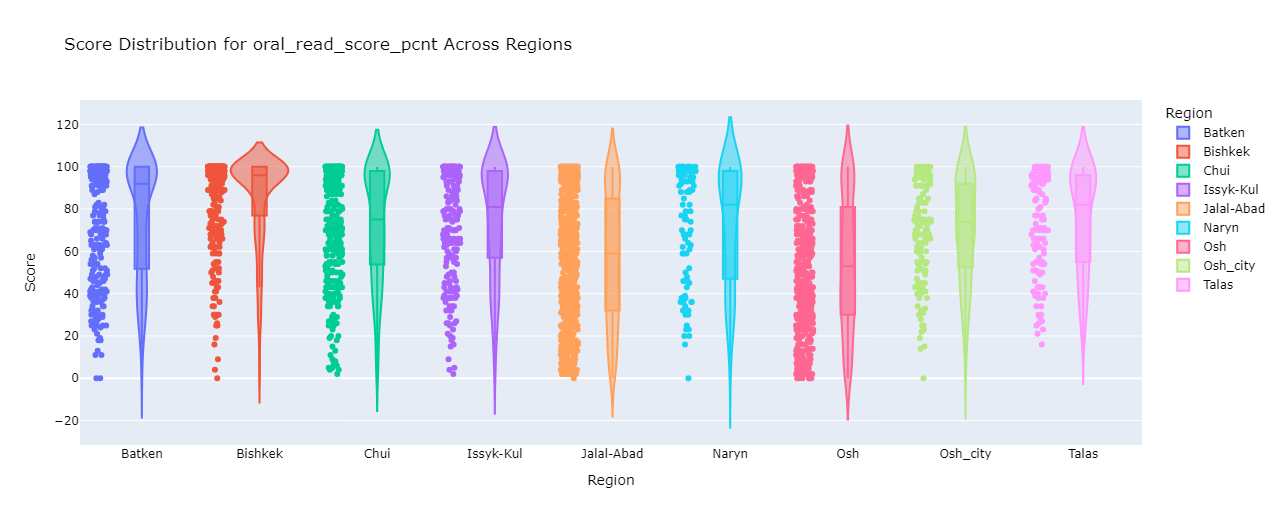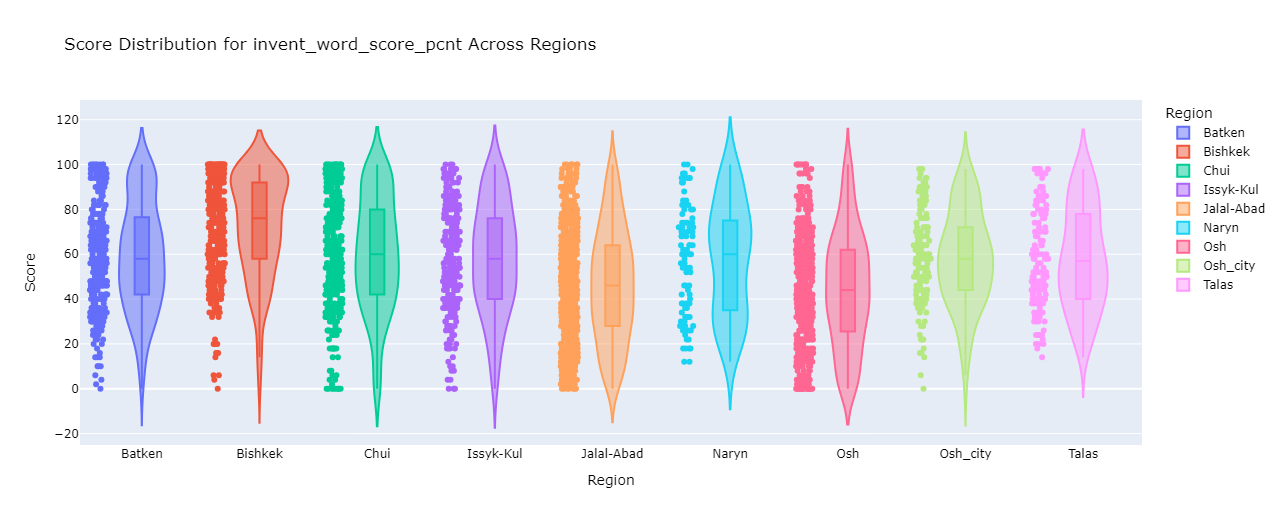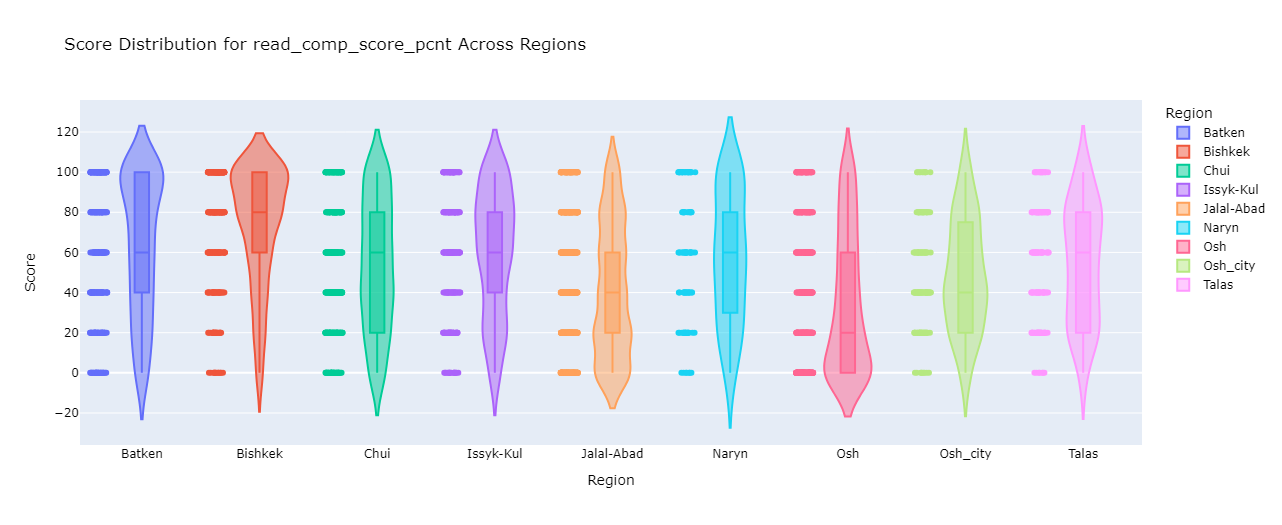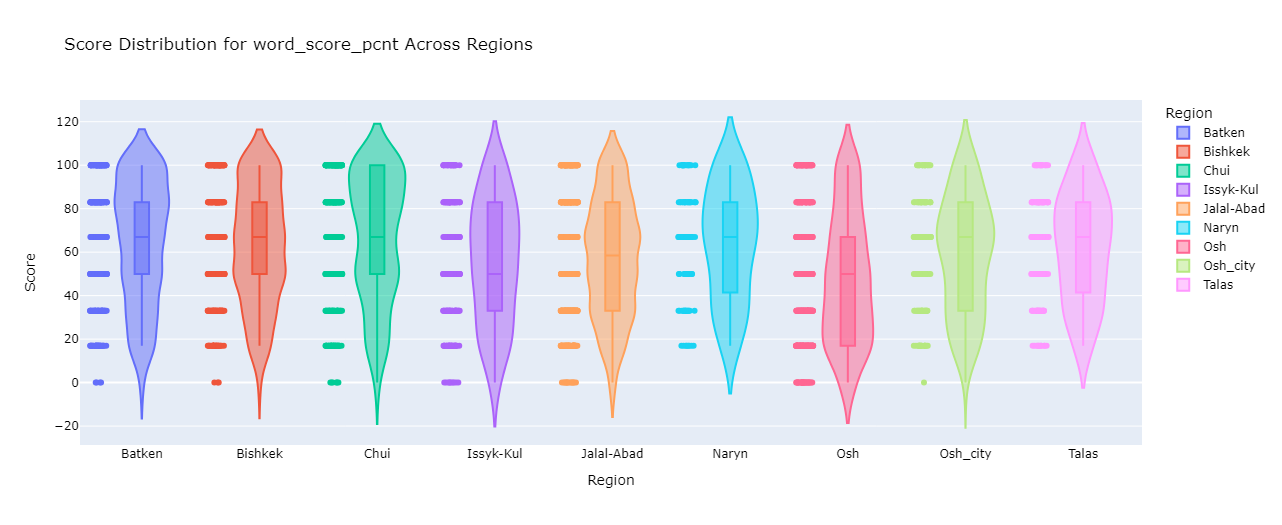

**Oral Reading Score**
We can see that Bishkek has one heck of a tail at the upper end, almost looks like a glassblowers pipe! And the box plot is super tight!

Other regions have similar candles, with the distribution towards the top.
The interesting outliers here appear to be Jalal-Abad, Osh, and Osh City. These three , in reviewing the box plot, have a much wider range and we can see don't have the "tail" appearing at the end of the violin chart. Definitely something up with these three regions as a whole!

**Invented Word**
Aside from Bishkek, we're seeing a pretty standard distribution across the board.

**Reading Comp Score Review**
Reading comprehension followed the story/oral reading score.
If students did not fail to read the first line of words, they would be asked questions. If they did not reach certain parts of the story in time, they might not be asked certain questions.
We would expect, as a result, the results might be a bit smoother as some students wouldn't get as far along to receive the next reading comprehension question.

Osh, Talas, and Jalal Abad show a strong concentration and grouping at the bottom of the violin chart. Osh especially is showing some interesting, and perhaps troubling, results. The other regions appear to have a more normal distribution in comparison.

**Word Score Pcnt**
This subtask involved silent reading comprehension.
We're seeing similar patterns to the prior two. However, a really, really interesting note is that the students in Chui seemed to have done a bit better, with a wider distribution than all the other regions, even Bishkek, which did an amazing job on the oral reading and oral reading comprehension questions compared to the other regions. Interesting!


#Statistics

##ANOVA -one way test between regions for all subtasks

In [290]:
# One-way ANOVA across all regions
model = ols('oral_read_score_pcnt ~ C(region)', data=base).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df          F        PR(>F)
C(region)  2.855733e+05     8.0  46.892108  6.772220e-71
Residual   1.958699e+06  2573.0        NaN           NaN


In [291]:
# One-way ANOVA across all regions
model = ols('read_comp_score_pcnt ~ C(region)', data=base).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df          F        PR(>F)
C(region)  3.780006e+05     8.0  46.015606  1.379932e-69
Residual   2.642026e+06  2573.0        NaN           NaN


In [292]:
model=ols('word_score_pcnt ~ C(region)', data=base).fit()
anova_Table=sm.stats.anova_lm(model, typ=2)
print(anova_Table)

                 sum_sq      df          F        PR(>F)
C(region)  8.841147e+04     8.0  14.475468  7.590315e-21
Residual   1.964381e+06  2573.0        NaN           NaN


In [293]:
model=ols('invent_word_score_pcnt ~ C(region)', data=base).fit()
anova_Table=sm.stats.anova_lm(model, typ=2)
print(anova_Table)

                 sum_sq      df          F        PR(>F)
C(region)  2.059824e+05     8.0  43.353588  1.356524e-65
Residual   1.528111e+06  2573.0        NaN           NaN


In [313]:
model=ols('list_comp_score_pcnt ~ C(region)', data=base).fit()
anova_Table=sm.stats.anova_lm(model, typ=2)
print(anova_Table)

                 sum_sq      df          F        PR(>F)
C(region)  1.631410e+05     8.0  20.857986  6.518357e-31
Residual   2.515593e+06  2573.0        NaN           NaN


Quick recap - there is a significant difference between regions for all four subtask scores. Will need to do a Tukey test to dig in more!

##ANOVA - one way test - Language within a region by subtask

###Oral Reading Score Score - between languages within a region

In [294]:
# List of regions
regions = base['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = base[base['region'] == region]
    model = ols('oral_read_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   27057.548323    3.0  13.419231  3.091704e-08
Residual     199616.305498  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df          F    PR(>F)
C(language)   10392.732819    1.0  24.361557  0.000001
Residual     134806.801772  316.0        NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df         F    PR(>F)
C(language)      83.601680    1.0  0.118575  0.730799
Residual     239013.759024  339.0       NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)    1710.704114    1.0  2.477204  0.116894
Residual     157451.943712  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   16005.042902    2.0  8.860669  0.000162
Residual     521118.067443  577.0       NaN       NaN


ANOVA for Region: Naryn
       

Takeaways of ANOVA test within regions for the oral reading  subtask score - did language matter within the region?

1. Batken - significant as p <= .05
2. Bishkek - significant as p <= .05
3. Chui - not significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05


###Reading Comprehension - between languages within a region

In [295]:
# List of regions
regions = base['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = base[base['region'] == region]
    model = ols('read_comp_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   98955.200191    3.0  38.820759  3.400542e-21
Residual     252353.769909  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df         F        PR(>F)
C(language)   20831.193483    1.0  26.74821  4.122955e-07
Residual     246097.108404  316.0       NaN           NaN


ANOVA for Region: Chui
                    sum_sq     df          F    PR(>F)
C(language)   13570.677133    1.0  13.644068  0.000257
Residual     337176.536943  339.0        NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)      36.469356    1.0  0.037748  0.846124
Residual     220278.313253  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   13102.068924    2.0  6.306486  0.001953
Residual     599374.482800  577.0       NaN       NaN


ANOVA for Region: N

Oral Reading Comprehension  subtask, significance of language within regions
1. Batken - significant as p <= .05
2. Bishkek -  significant as p >= .05
3. Chui -  significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - not significant as p >= .05
9. Talas - not significant as p > .05

###Silent Reading Comprehension - between languages within a region

In [296]:
# List of regions
regions = base['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = base[base['region'] == region]
    model = ols('word_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   94895.942044    3.0  65.745064  1.251100e-32
Residual     142895.871910  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df         F    PR(>F)
C(language)    4653.912911    1.0  6.647983  0.010379
Residual     221215.433001  316.0       NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df           F        PR(>F)
C(language)   72443.010357    1.0  116.787349  1.371596e-23
Residual     210281.171461  339.0         NaN           NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)     117.355436    1.0  0.146141  0.702606
Residual     183089.966303  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df          F        PR(>F)
C(language)   20632.504730    2.0  15.301226  3.349587e-07
Residual     389019.652166  577.0        NaN           NaN


A

Word Score Percent subtask, significance of language within regions
1. Batken - significant as p <= .05
2. Bishkek - not significant as p >= .05
3. Chui -  significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05

###Invented Word Score - between languages within a region

In [297]:
# List of regions
regions = base['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = base[base['region'] == region]
    model = ols('invent_word_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df        F    PR(>F)
C(language)    7494.583537    3.0  4.47693  0.004307
Residual     165730.479586  297.0      NaN       NaN


ANOVA for Region: Bishkek
                    sum_sq     df          F    PR(>F)
C(language)    8195.408011    1.0  16.791331  0.000053
Residual     154231.308970  316.0        NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df         F    PR(>F)
C(language)     574.067017    1.0  0.890813  0.345929
Residual     218461.827411  339.0       NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F   PR(>F)
C(language)       7.357255    1.0  0.012344  0.91163
Residual     135886.903614  228.0       NaN      NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   10205.082087    2.0  8.288309  0.000283
Residual     355219.159292  577.0       NaN       NaN


ANOVA for Region: Naryn
                   sum_sq   

Takeaways of ANOVA test within regions for the invented word subtask score - did language matter within the region?

1. Batken - significant as p <= .05
2. Bishkek - significant as p <= .05
3. Chui - not significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05


###List Comp Score - between languages within a region

In [314]:
# List of regions
regions = base['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = base[base['region'] == region]
    model = ols('list_comp_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df           F        PR(>F)
C(language)  166955.871637    3.0  113.566731  5.288427e-49
Residual     145541.138330  297.0         NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df          F    PR(>F)
C(language)    9940.834999    1.0  16.274167  0.000069
Residual     193023.944875  316.0        NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df          F        PR(>F)
C(language)   65526.596570    1.0  88.290836  8.617193e-19
Residual     251594.811055  339.0        NaN           NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)     267.365767    1.0  0.329287  0.566645
Residual     185125.677711  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df           F        PR(>F)
C(language)  155007.103297    2.0  104.437859  1.948187e-39
Residual     428192.896703  577.0         NaN           N

##Tukey Test

In [316]:
# Create a combined category for region and language
base['Region_Language'] = base['region'] + "_" + base['language']


<ipython-input-316-136fc0f7eed0>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###Oral Reading Score Tukey Test

In [317]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(base['oral_read_score_pcnt'], base['Region_Language'])
oralreadtukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
oralreadtukey
# Print results
print(tukey_results)

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-24.5038,0.0002,-42.4541,-6.5534,True
1,Batken_Kyrgyz,Batken_Tajik,-13.0143,0.7398,-32.7575,6.7289,False
2,Batken_Kyrgyz,Batken_Uzbek,4.4900,0.9999,-8.6377,17.6178,False
3,Batken_Kyrgyz,Bishkek_Kyrgyz,-0.0554,1.0000,-12.0320,11.9213,False
4,Batken_Kyrgyz,Bishkek_Russian,11.5873,0.0239,0.6447,22.5299,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,2.6264,1.0000,-10.9328,16.1855,False
249,Osh_city_Russian,Talas_Russian,2.0864,1.0000,-16.0328,20.2055,False
250,Osh_city_Uzbek,Talas_Kyrgyz,28.8900,0.1670,-3.6573,61.4373,False
251,Osh_city_Uzbek,Talas_Russian,28.3500,0.3062,-6.3455,63.0455,False


             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -24.5038 0.0002 -42.4541  -6.5534   True
     Batken_Kyrgyz       Batken_Tajik -13.0143 0.7398 -32.7575   6.7289  False
     Batken_Kyrgyz       Batken_Uzbek     4.49 0.9999  -8.6377  17.6178  False
     Batken_Kyrgyz     Bishkek_Kyrgyz  -0.0554    1.0  -12.032  11.9213  False
     Batken_Kyrgyz    Bishkek_Russian  11.5873 0.0239   0.6447  22.5299   True
     Batken_Kyrgyz        Chui_Kyrgyz  -6.9529 0.7847 -17.8005   3.8948  False
     Batken_Kyrgyz       Chui_Russian  -5.9504 0.9726 -17.5979   5.6971  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -2.5818    1.0 -13.8423   8.6788  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -8.6674 0.8945 -23.4748     6.14  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -20.0358    0.

###Reading Comprehension Score Tukey Test

In [299]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(base['read_comp_score_pcnt'], base['Region_Language'])

# Print results
print(tukey_results)
readcomptukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
readcomptukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -36.7744    0.0 -57.1362 -16.4127   True
     Batken_Kyrgyz       Batken_Tajik -22.8095   0.04  -45.205  -0.4141   True
     Batken_Kyrgyz       Batken_Uzbek  18.6528 0.0014   3.7615  33.5441   True
     Batken_Kyrgyz     Bishkek_Kyrgyz   -0.732    1.0 -14.3176  12.8536  False
     Batken_Kyrgyz    Bishkek_Russian  15.7513  0.001   3.3387  28.1639   True
     Batken_Kyrgyz        Chui_Kyrgyz  -5.2596  0.997 -17.5645   7.0453  False
     Batken_Kyrgyz       Chui_Russian -18.0317 0.0002 -31.2439  -4.8196   True
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -4.5043 0.9998 -17.2776    8.269  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -5.3929    1.0 -22.1895  11.4037  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -18.4194    0.

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-36.7744,0.0000,-57.1362,-16.4127,True
1,Batken_Kyrgyz,Batken_Tajik,-22.8095,0.0400,-45.2050,-0.4141,True
2,Batken_Kyrgyz,Batken_Uzbek,18.6528,0.0014,3.7615,33.5441,True
3,Batken_Kyrgyz,Bishkek_Kyrgyz,-0.7320,1.0000,-14.3176,12.8536,False
4,Batken_Kyrgyz,Bishkek_Russian,15.7513,0.0010,3.3387,28.1639,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,9.6364,0.8174,-5.7442,25.0170,False
249,Osh_city_Russian,Talas_Russian,2.6364,1.0000,-17.9168,23.1896,False
250,Osh_city_Uzbek,Talas_Kyrgyz,10.0000,1.0000,-26.9196,46.9196,False
251,Osh_city_Uzbek,Talas_Russian,3.0000,1.0000,-36.3564,42.3564,False


###Silent Reading Score Tukey Test

In [300]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(base['word_score_pcnt'], base['Region_Language'])
wordscoretukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# Print results
print(tukey_results)
wordscoretukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -16.8222 0.0531 -33.7312   0.0868  False
     Batken_Kyrgyz       Batken_Tajik   18.069 0.0696  -0.5288  36.6669  False
     Batken_Kyrgyz       Batken_Uzbek  33.5561    0.0  21.1899  45.9223   True
     Batken_Kyrgyz     Bishkek_Kyrgyz   3.7272 0.9999  -7.5547  15.0091  False
     Batken_Kyrgyz    Bishkek_Russian  11.5183 0.0108   1.2104  21.8261   True
     Batken_Kyrgyz        Chui_Kyrgyz  24.2063    0.0  13.9879  34.4246   True
     Batken_Kyrgyz       Chui_Russian  -5.3032 0.9856  -16.275   5.6686  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz   0.7574    1.0  -9.8499  11.3647  False
     Batken_Kyrgyz  Issyk-Kul_Russian   2.3513    1.0 -11.5971  16.2998  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz   6.6846 0.598

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-16.8222,0.0531,-33.7312,0.0868,False
1,Batken_Kyrgyz,Batken_Tajik,18.0690,0.0696,-0.5288,36.6669,False
2,Batken_Kyrgyz,Batken_Uzbek,33.5561,0.0000,21.1899,45.9223,True
3,Batken_Kyrgyz,Bishkek_Kyrgyz,3.7272,0.9999,-7.5547,15.0091,False
4,Batken_Kyrgyz,Bishkek_Russian,11.5183,0.0108,1.2104,21.8261,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,9.4818,0.5058,-3.2907,22.2544,False
249,Osh_city_Russian,Talas_Russian,-2.0182,1.0000,-19.0862,15.0498,False
250,Osh_city_Uzbek,Talas_Kyrgyz,9.7000,1.0000,-20.9592,40.3592,False
251,Osh_city_Uzbek,Talas_Russian,-1.8000,1.0000,-34.4828,30.8828,False


###Invented Word Score Tukey Test

In [319]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(base['invent_word_score_pcnt'], base['Region_Language'])
inventtukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# Print results
print(tukey_results)
inventtukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -15.4887 0.0715 -31.4691   0.4917  False
     Batken_Kyrgyz       Batken_Tajik  -6.5238 0.9996 -24.1004  11.0527  False
     Batken_Kyrgyz       Batken_Uzbek  -2.8141    1.0 -14.5012    8.873  False
     Batken_Kyrgyz     Bishkek_Kyrgyz   3.3754    1.0  -7.2869  14.0377  False
     Batken_Kyrgyz    Bishkek_Russian  13.7143 0.0001   3.9725   23.456   True
     Batken_Kyrgyz        Chui_Kyrgyz   -3.984 0.9982 -13.6413   5.6732  False
     Batken_Kyrgyz       Chui_Russian  -1.3571    1.0 -11.7264   9.0121  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -4.8812 0.9842 -14.9061   5.1436  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -4.4821 0.9999 -17.6646   8.7003  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -16.3877    0.

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-15.4887,0.0715,-31.4691,0.4917,False
1,Batken_Kyrgyz,Batken_Tajik,-6.5238,0.9996,-24.1004,11.0527,False
2,Batken_Kyrgyz,Batken_Uzbek,-2.8141,1.0000,-14.5012,8.8730,False
3,Batken_Kyrgyz,Bishkek_Kyrgyz,3.3754,1.0000,-7.2869,14.0377,False
4,Batken_Kyrgyz,Bishkek_Russian,13.7143,0.0001,3.9725,23.4560,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,-2.3564,1.0000,-14.4275,9.7147,False
249,Osh_city_Russian,Talas_Russian,0.3636,1.0000,-15.7671,16.4943,False
250,Osh_city_Uzbek,Talas_Kyrgyz,16.0800,0.9354,-12.8954,45.0554,False
251,Osh_city_Uzbek,Talas_Russian,18.8000,0.8539,-12.0879,49.6879,False


###List Comprehension Score Tukey Test

In [318]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(base['list_comp_score_pcnt'], base['Region_Language'])
listcomptukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# Print results
print(tukey_results)
listcomptukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -33.5414    0.0 -51.5349 -15.5478   True
     Batken_Kyrgyz       Batken_Tajik  29.4762    0.0   9.6854  49.2669   True
     Batken_Kyrgyz       Batken_Uzbek  37.3472    0.0  24.1878  50.5065   True
     Batken_Kyrgyz     Bishkek_Kyrgyz   7.2746  0.859  -4.7308  19.2801  False
     Batken_Kyrgyz    Bishkek_Russian  18.6614    0.0   7.6924  29.6303   True
     Batken_Kyrgyz        Chui_Kyrgyz  17.0972    0.0   6.2234  27.9709   True
     Batken_Kyrgyz       Chui_Russian -10.9683 0.0992 -22.6438   0.7073  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  10.9862 0.0683  -0.3015  22.2739  False
     Batken_Kyrgyz  Issyk-Kul_Russian   8.5804 0.9055  -6.2627  23.4234  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz   4.0014 0.998

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-33.5414,0.0000,-51.5349,-15.5478,True
1,Batken_Kyrgyz,Batken_Tajik,29.4762,0.0000,9.6854,49.2669,True
2,Batken_Kyrgyz,Batken_Uzbek,37.3472,0.0000,24.1878,50.5065,True
3,Batken_Kyrgyz,Bishkek_Kyrgyz,7.2746,0.8590,-4.7308,19.2801,False
4,Batken_Kyrgyz,Bishkek_Russian,18.6614,0.0000,7.6924,29.6303,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,12.6182,0.1114,-0.9736,26.2099,False
249,Osh_city_Russian,Talas_Russian,-11.6818,0.7794,-29.8446,6.4809,False
250,Osh_city_Uzbek,Talas_Kyrgyz,-13.2000,0.9986,-45.8256,19.4256,False
251,Osh_city_Uzbek,Talas_Russian,-37.5000,0.0185,-72.2790,-2.7210,True


##Tukey Analysis

In [302]:
oralreadtukey[oralreadtukey['reject'] == True]
#this is all of the cases where region + language led to rejecting the null hypothesis for this subtasks
#To guide interpretation - Batken kyrgyz did 24 points better than batken russian
#I need to review all of these, and most importantly, determine each direction!

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-24.5038,0.0002,-42.4541,-6.5534,True
4,Batken_Kyrgyz,Bishkek_Russian,11.5873,0.0239,0.6447,22.5299,True
9,Batken_Kyrgyz,Jalal-Abad_Kyrgyz,-20.0358,0.0000,-30.0235,-10.0482,True
10,Batken_Kyrgyz,Jalal-Abad_Russian,-16.9407,0.0000,-28.3141,-5.5673,True
11,Batken_Kyrgyz,Jalal-Abad_Uzbek,-31.9597,0.0000,-44.4631,-19.4564,True
...,...,...,...,...,...,...,...
231,Osh_Kyrgyz,Talas_Russian,19.3670,0.0051,2.7903,35.9436,True
232,Osh_Russian,Osh_Uzbek,21.7829,0.0028,3.7487,39.8171,True
234,Osh_Russian,Osh_city_Russian,23.0215,0.0000,9.9058,36.1373,True
236,Osh_Russian,Talas_Kyrgyz,25.6479,0.0000,12.2025,39.0933,True


In [303]:
readcomptukey[readcomptukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-36.7744,0.0000,-57.1362,-16.4127,True
1,Batken_Kyrgyz,Batken_Tajik,-22.8095,0.0400,-45.2050,-0.4141,True
2,Batken_Kyrgyz,Batken_Uzbek,18.6528,0.0014,3.7615,33.5441,True
4,Batken_Kyrgyz,Bishkek_Russian,15.7513,0.0010,3.3387,28.1639,True
6,Batken_Kyrgyz,Chui_Russian,-18.0317,0.0002,-31.2439,-4.8196,True
...,...,...,...,...,...,...,...
232,Osh_Russian,Osh_Uzbek,47.0526,0.0000,26.5958,67.5095,True
233,Osh_Russian,Osh_city_Kyrgyz,42.1053,0.0000,14.5213,69.6892,True
234,Osh_Russian,Osh_city_Russian,27.4163,0.0000,12.5386,42.2940,True
236,Osh_Russian,Talas_Kyrgyz,37.0526,0.0000,21.8011,52.3042,True


In [304]:
wordscoretukey[wordscoretukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
2,Batken_Kyrgyz,Batken_Uzbek,33.5561,0.0000,21.1899,45.9223,True
4,Batken_Kyrgyz,Bishkek_Russian,11.5183,0.0108,1.2104,21.8261,True
5,Batken_Kyrgyz,Chui_Kyrgyz,24.2063,0.0000,13.9879,34.4246,True
15,Batken_Kyrgyz,Osh_Russian,-20.7695,0.0000,-32.4313,-9.1078,True
16,Batken_Kyrgyz,Osh_Uzbek,34.1357,0.0000,17.5625,50.7089,True
...,...,...,...,...,...,...,...
237,Osh_Russian,Talas_Russian,19.9053,0.0049,2.9173,36.8932,True
239,Osh_Uzbek,Osh_city_Russian,-32.9818,0.0000,-50.0498,-15.9138,True
240,Osh_Uzbek,Osh_city_Uzbek,-33.2000,0.0413,-65.8828,-0.5172,True
241,Osh_Uzbek,Talas_Kyrgyz,-23.5000,0.0002,-40.7941,-6.2059,True


In [305]:
inventtukey[inventtukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
4,Batken_Kyrgyz,Bishkek_Russian,13.7143,0.0001,3.9725,23.4560,True
9,Batken_Kyrgyz,Jalal-Abad_Kyrgyz,-16.3877,0.0000,-25.2792,-7.4961,True
10,Batken_Kyrgyz,Jalal-Abad_Russian,-11.3477,0.0103,-21.4730,-1.2224,True
11,Batken_Kyrgyz,Jalal-Abad_Uzbek,-23.8753,0.0000,-35.0066,-12.7441,True
14,Batken_Kyrgyz,Osh_Kyrgyz,-19.7971,0.0000,-28.8241,-10.7700,True
...,...,...,...,...,...,...,...
228,Osh_Kyrgyz,Osh_city_Russian,16.5763,0.0000,6.7602,26.3924,True
230,Osh_Kyrgyz,Talas_Kyrgyz,14.2199,0.0001,4.0565,24.3833,True
231,Osh_Kyrgyz,Talas_Russian,16.9399,0.0069,2.1825,31.6974,True
234,Osh_Russian,Osh_city_Russian,15.3907,0.0005,3.7144,27.0671,True
